# Sun Baseline and Delay Determination

Split from `diagnostic_sun.ipynb`: shared setup cells followed by baseline and delay estimation workflows.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time
from ugradiolab import NCH_LON_DEG

from utils.constants import (
    F_S_HZ,
    N_FFT,
    LO1_HZ,
    LO2_HZ,
    IF1_BPF_CENTER_HZ,
    IF1_BPF_HALF_BW_HZ,
    PLOT_BAND_GHZ,
    F_RF0_HZ,
)

from utils.captures import load_capture_series
from utils.chips import segment_capture_times_by_gap
from utils.dc import local_real_dc_correction
from utils.plotter import (
    plot_baseline_vs_frequency,
    plot_fringe_rate_vs_frequency,
    plot_interval_baseline,
    plot_lag_delay_summary,
)


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/sun_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
captures = load_capture_series(paths)

N_CH = captures.N_CH
DF_HZ = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {captures.N_cap} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')
print(f'Analysis band : {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp = np.abs(captures.corr).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4g}')


Loaded 8716 captures  |  10.2900 -- 10.5398 GHz  |  244.1 kHz/ch
Analysis band : 10.415 -- 10.485 GHz
Masked : [0, 256, 512, 768]  (['10.2900 GHz', '10.3525 GHz', '10.4150 GHz', '10.4775 GHz'])
Peak   : 2.131


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    return get_sun(Time(unix_t, format='unix')).ra.deg

order = np.argsort(captures.unix_mid)
captures_s = captures.take(order)
unix_sort = captures_s.unix_mid
N_cap = captures_s.N_cap

lst_arr     = np.array([_lst_deg(t)    for t in unix_sort])
sun_ra_arr  = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg      = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

chip_info = segment_capture_times_by_gap(
    unix_time_start_sorted=captures_s.unix_time_start,
    unix_time_end_sorted=captures_s.unix_time_end,
    unix_sorted=unix_sort,
    ha_deg=ha_deg,
)
chip_slices = chip_info.chip_slices
corr_chips = [captures_s.corr[s] for s in chip_slices]
unix_chips = chip_info.unix_chips
ha_chips = chip_info.ha_chips
N_caps = chip_info.N_caps
cap_chip = chip_info.cap_chip
_gaps = chip_info.gap_s

print(f'Chip split threshold: {chip_info.split_gap_threshold_sec:.3f} s')
if chip_info.gap_break_indices.size:
    for break_idx, gap_s in zip(chip_info.gap_break_indices, chip_info.gap_break_values_sec):
        print(f'Break at index {break_idx-1}→{break_idx}: {gap_s:.1f} s  ({gap_s/60:.1f} min)')
else:
    print('No chip breaks detected.')

for chip_idx, (n_cap_chip, ha_chip) in enumerate(zip(N_caps, ha_chips)):
    print(f'Chip {chip_idx}: {n_cap_chip} captures,  HA {ha_chip.min():.2f}° → {ha_chip.max():.2f}°')

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak = captures_s.corr[:, k_peak]
amp_peak = np.abs(vis_peak) / AMP_PEAK
dphase_peak = np.rad2deg(np.angle(vis_peak[1:] * np.conj(vis_peak[:-1])))

print(f'Sun RA   : {sun_ra_arr.min():.4f} -- {sun_ra_arr.max():.4f} deg  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f} deg)')
print(f'HA range : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
if dphase_peak.size:
    print(f'ΔPhase(prev) : mean={dphase_peak.mean():.1f}°,  std={dphase_peak.std():.1f}°')
else:
    print('ΔPhase(prev) : n/a (need at least 2 captures)')


Chip split threshold: 5.000 s
Break at index 5538→5539: 153.8 s  (2.6 min)
Break at index 5941→5942: 133.8 s  (2.2 min)
Break at index 8627→8628: 35.9 s  (0.6 min)
Chip 0: 5539 captures,  HA -80.78° → -8.43°
Chip 1: 403 captures,  HA -7.78° → -3.50°
Chip 2: 2686 captures,  HA -2.94° → 26.06°
Chip 3: 88 captures,  HA 26.21° → 27.14°
Sun RA   : 359.6663 -- 359.9396 deg  (span 0.2733 deg)
HA range : -80.78° -> 27.14°  (107.93° span)
Peak channel : k=579,  f_sky=10.4314 GHz
Amp  (norm)  : mean=0.497,  std=0.089
ΔPhase(prev) : mean=0.0°,  std=3.7°


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_4866/2792095158.py:54: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


In [4]:
# ---------------------------------------------------------------------------
# Local DC correction per chip — rolling real-median pedestal subtraction.
# Each chip is corrected independently, and the local window never crosses
# chip boundaries.
# corr_chips[c]    : (N_caps[c], N_CH)  raw complex visibility
# corr_dc_chips[c] : (N_caps[c], N_CH)  locally DC-corrected complex visibility
# corr_dc          : (N_cap, N_CH)      full sequence (for non-gap-sensitive cells)
# ---------------------------------------------------------------------------

NOMINAL_FRINGE_PERIOD_SEC = 40.0
LOCAL_DC_PERIODS = 2.5
LOCAL_DC_WINDOW_SEC = NOMINAL_FRINGE_PERIOD_SEC * LOCAL_DC_PERIODS

dc_result = local_real_dc_correction(
    corr_chips=corr_chips,
    unix_chips=unix_chips,
    bad_channels=BAD_CHANNELS,
    nominal_fringe_period_sec=NOMINAL_FRINGE_PERIOD_SEC,
    window_periods=LOCAL_DC_PERIODS,
)

corr_dc_chips = dc_result.corr_dc_chips
corr_dc = dc_result.corr_dc
real_dc_offset_chips = dc_result.real_offset_chips

print(f'Local DC target window: {dc_result.window_sec:.1f} s')
for chip_idx, (cadence_sec, window_caps) in enumerate(
    zip(dc_result.median_cadence_sec_chips, dc_result.window_caps_chips)
):
    cadence_label = f'{cadence_sec:.2f} s' if np.isfinite(cadence_sec) else 'single capture'
    print(f'Chip {chip_idx}: median cadence {cadence_label},  local window {window_caps} captures')


Local DC target window: 100.0 s
Chip 0: median cadence 2.66 s,  local window 39 captures
Chip 1: median cadence 2.51 s,  local window 41 captures
Chip 2: median cadence 2.51 s,  local window 41 captures
Chip 3: median cadence 2.50 s,  local window 41 captures


## Fringe frequency → baseline conversion

### Fringe phase model

For a two-element interferometer with east-west baseline $B_\mathrm{EW}$, the geometric path-length difference is

$$\Delta l = \mathbf{b}\cdot\hat{s} = -B_\mathrm{EW}\cos\delta\sin h$$

because the geographic east unit vector is always perpendicular to Earth's rotation axis (i.e. it has no component along the NCP direction), so **latitude does not appear**. The fringe phase is

$$\varphi(h) = -\frac{2\pi f_\mathrm{obs}}{c}\,B_\mathrm{EW}\cos\delta\sin h + \varphi_0$$

### Instantaneous fringe frequency

Differentiating with respect to $h$ and converting to **cycles per degree of HA**:

$$f_\mathrm{fringe}\,[\mathrm{cyc\,deg^{-1}}] = \frac{f_\mathrm{obs}}{c}\,B_\mathrm{EW}\cos\delta\,|\cos h|\cdot\frac{\pi}{180}$$

Note: it is $|\cos h|$, not $|\sin h|$. The fringe rate is **maximum at transit** ($h=0$, source moving fastest in E-W) and zero at $h=\pm90°$.

### Solving for $B_\mathrm{EW}$

$$\boxed{B_\mathrm{EW} = \frac{f_\mathrm{fringe}\cdot c}{f_\mathrm{obs}\,\cos\delta\,|\cos\bar{h}|\cdot(\pi/180)}}$$

where $\bar{h}$ is the mean hour angle during the observation.

### Parameters (NCH X-band interferometer)

| Symbol | Value | Note |
|--------|-------|------|
| $f_\mathrm{obs}$ | $F\_SKY\_GHZ[K\_CH]$ GHz | sky frequency of the channel |
| $c$ | $3\times10^8$ m s$^{-1}$ | |
| $\delta_\odot$ | $\approx -1°$ to $+23°$ | Sun's declination (seasonal) |
| $\bar{h}$ | from `ha_deg.mean()` | mean HA of the capture window |

### Numerical shorthand

With the Sun near the equinox ($\cos\delta\approx1$):

$$B_\mathrm{EW} \approx \frac{1.034}{|\cos\bar{h}|}\;\mathrm{m}\quad\text{per cyc deg}^{-1}\text{ of fringe frequency at }f_\mathrm{obs}=9.9365\text{ GHz}$$

**Example:** $f_\mathrm{fringe}=0.600$ cyc deg$^{-1}$ at $\bar{h}\approx26°$ gives $B_\mathrm{EW}\approx1.15$ m, which is far below the nominal 15 m — meaning 0.600 cyc deg$^{-1}$ is likely a sidelobe. The fundamental fringe near transit from a 15 m baseline would appear at $f\approx f_\mathrm{obs}\cdot15\cdot1\cdot|\cos\bar{h}|\cdot\pi/180\,/c\approx3.8$ cyc deg$^{-1}$.

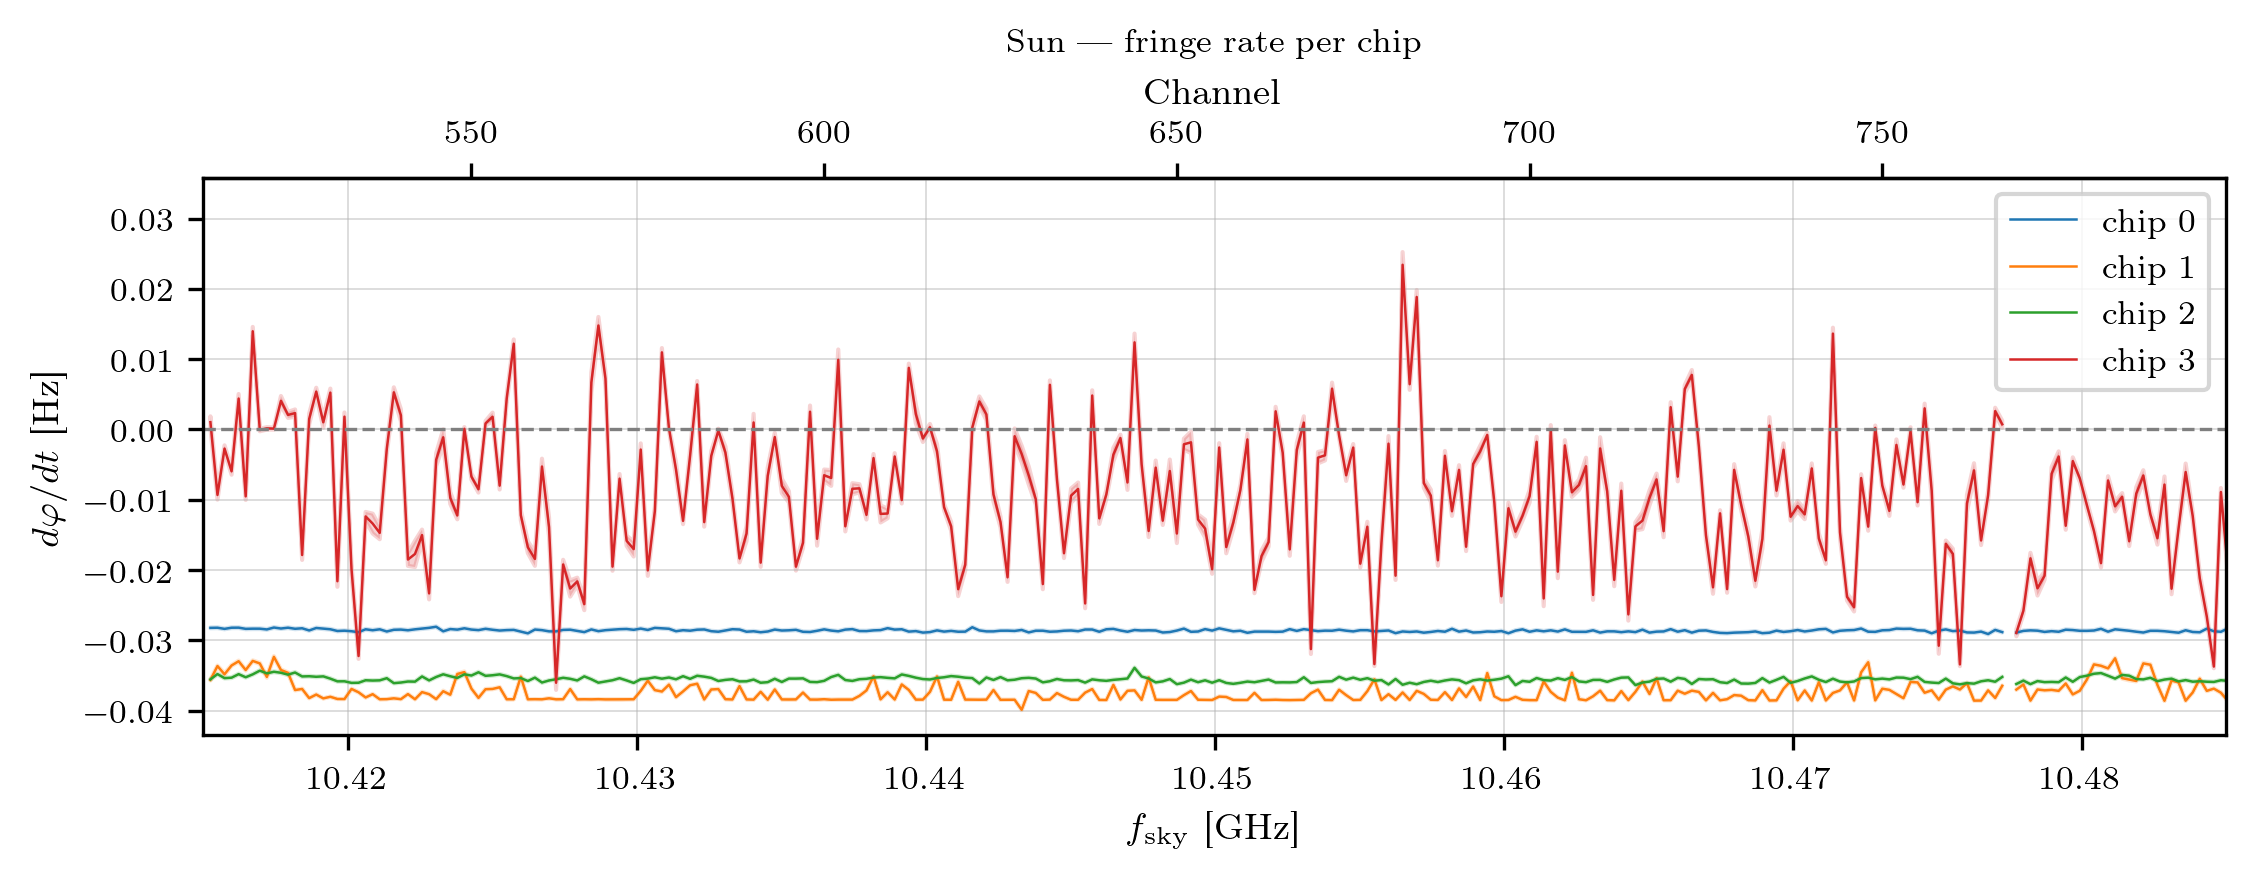

In [5]:
# ---------------------------------------------------------------------------
# Fringe rate: d φ / dt  — polyfit estimator per channel, per chip
# Phase is unwrapped within each chip to avoid the gap discontinuity.
# x: f_sky [GHz],  y: dφ/dt [Hz]
# ---------------------------------------------------------------------------

_omega_sid_deg_s = (2 * np.pi / 86164.1) * (180 / np.pi)  # deg/s

_dphi_dt_chips     = []
_dphi_dt_err_chips = []

for c, (ha_c, dc_c) in enumerate(zip(ha_chips, corr_dc_chips)):
    _t_ha_c = ha_c / _omega_sid_deg_s
    _phase_t_uw = np.unwrap(np.angle(dc_c), axis=0).astype(float)
    _phase_t_uw[:, BAD_CHANNELS] = np.nan
    _t_c = _t_ha_c - _t_ha_c.mean()

    _dphi_dt     = np.full(N_CH, np.nan)
    _dphi_dt_err = np.full(N_CH, np.nan)
    for k in range(N_CH):
        valid = np.isfinite(_phase_t_uw[:, k])
        if valid.sum() < 4:
            continue
        coeffs, (res, *_) = np.polynomial.polynomial.polyfit(
            _t_c[valid], _phase_t_uw[valid, k], 1, full=True
        )
        _dphi_dt[k] = coeffs[1] / (2 * np.pi)
        _n = valid.sum()
        _resid_std = np.sqrt(res[0] / (_n - 2)) if len(res) else np.nan
        _t_rms = np.sqrt(np.sum(_t_c[valid]**2))
        _dphi_dt_err[k] = _resid_std / (2 * np.pi * _t_rms)

    _dphi_dt_chips.append(_dphi_dt)
    _dphi_dt_err_chips.append(_dphi_dt_err)

fig, ax = plot_fringe_rate_vs_frequency(
    f_sky_ghz=F_SKY_GHZ,
    dphi_dt_chips=_dphi_dt_chips,
    dphi_dt_err_chips=_dphi_dt_err_chips,
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
)
plt.show()


Chip 0:  HA -80.78° → -8.43°  |  δ=-0.10°  |  B_EW = 15.659 ± 0.002 m
Chip 1:  HA -7.78° → -3.50°  |  δ=-0.06°  |  B_EW = 14.774 ± 0.015 m
Chip 2:  HA -2.94° → 26.06°  |  δ=-0.04°  |  B_EW = 14.382 ± 0.016 m
Chip 3:  HA 26.21° → 27.14°  |  δ=-0.03°  |  B_EW = 3.952 ± 0.336 m


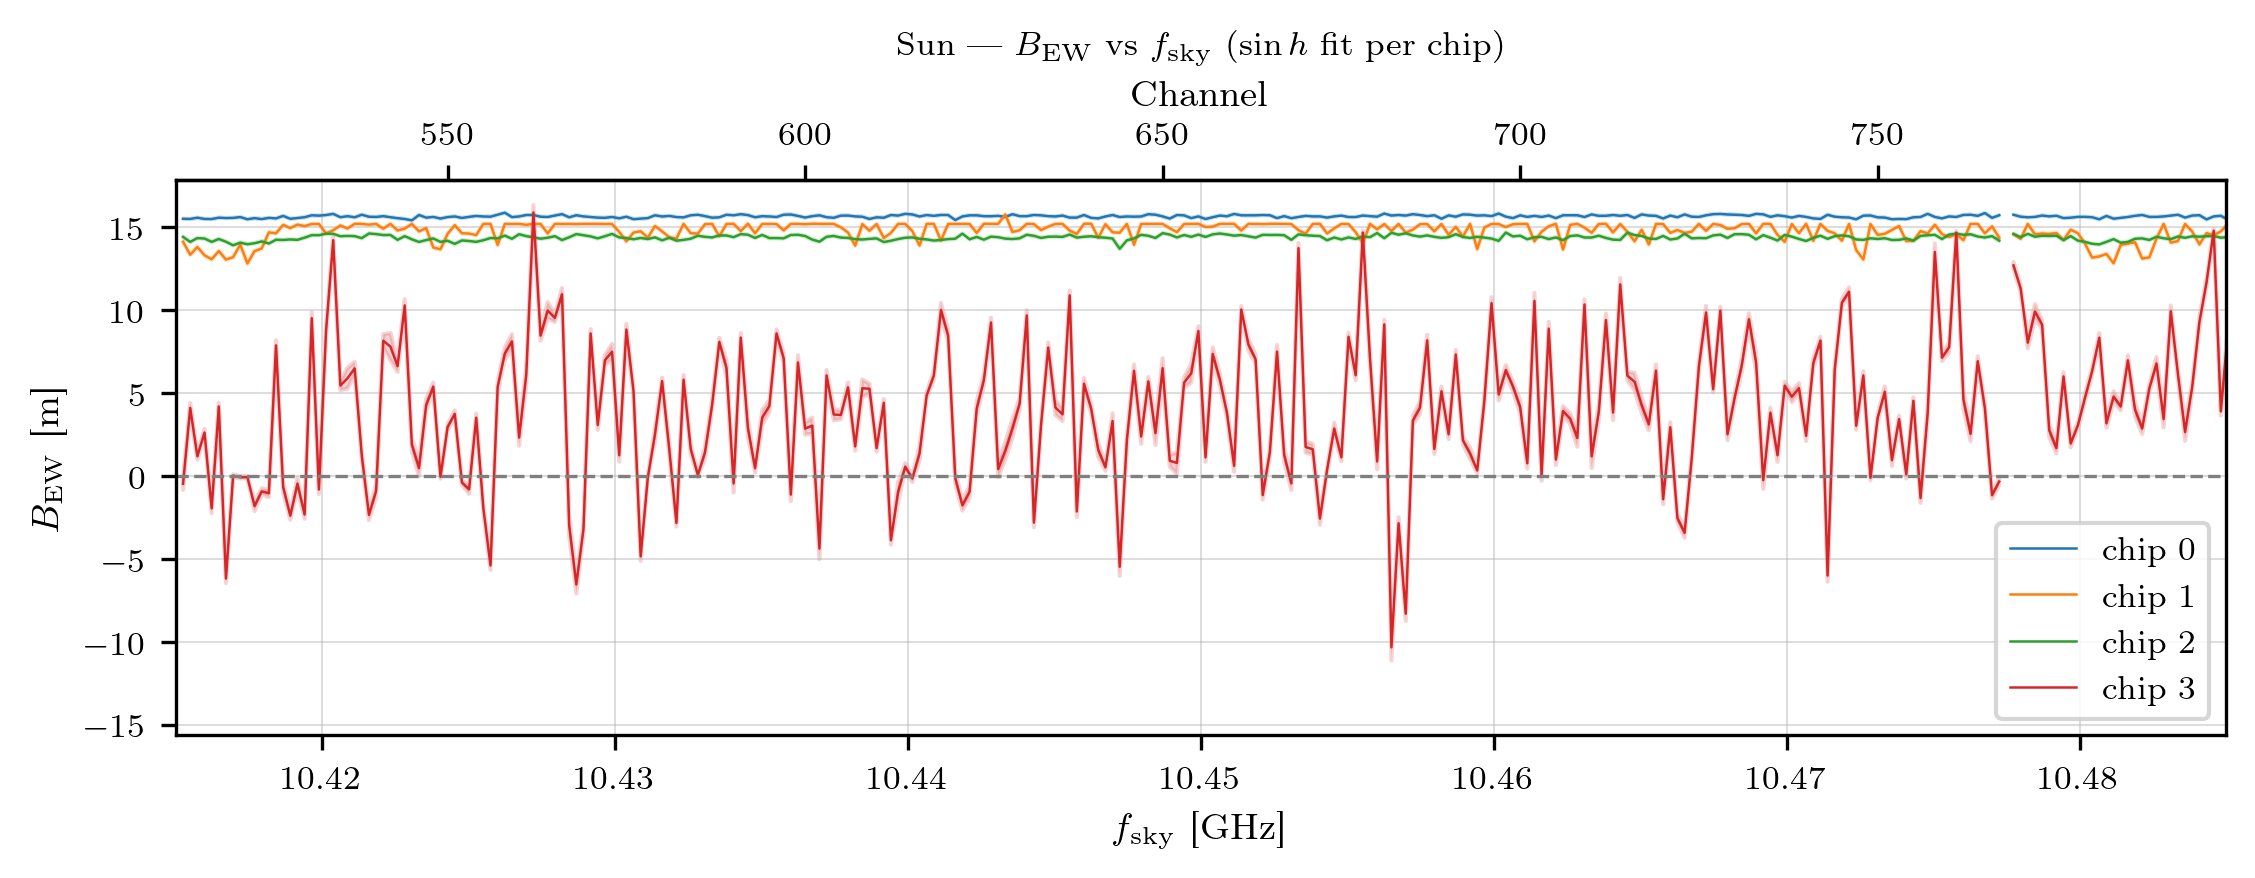

In [6]:
# ---------------------------------------------------------------------------
# Baseline B_EW vs f_sky — fit φ vs sin(h) per channel, per chip
#
# Model: φ(h) = A·sin(h) + φ_0
#   A = -(2π f_obs / c) · B_EW · cos(δ)
#   → B_EW(ν) = -A · c / (2π f_obs · cos(δ))
# ---------------------------------------------------------------------------

_C = 299792458.0

_B_EW_chips     = []
_B_EW_err_chips = []

for c, (ha_c, dc_c, unix_c) in enumerate(zip(ha_chips, corr_dc_chips, unix_chips)):
    _dec_deg = np.mean([get_sun(Time(t, format='unix')).dec.deg for t in unix_c])
    _cos_dec = np.cos(np.radians(_dec_deg))
    _sin_h   = np.sin(np.radians(ha_c))
    _sin_h_c = _sin_h - _sin_h.mean()

    _phase_uw = np.unwrap(np.angle(dc_c), axis=0).astype(float)
    _phase_uw[:, BAD_CHANNELS] = np.nan

    _B_EW     = np.full(N_CH, np.nan)
    _B_EW_err = np.full(N_CH, np.nan)
    for k in range(N_CH):
        valid = np.isfinite(_phase_uw[:, k])
        if valid.sum() < 4:
            continue
        coeffs, (res, *_) = np.polynomial.polynomial.polyfit(
            _sin_h_c[valid], _phase_uw[valid, k], 1, full=True
        )
        A = coeffs[1]
        _B_EW[k] = -A * _C / (2 * np.pi * F_SKY_GHZ[k] * 1e9 * _cos_dec)
        _n = valid.sum()
        _resid_std = np.sqrt(res[0] / (_n - 2)) if len(res) else np.nan
        _sin_h_rms = np.sqrt(np.sum(_sin_h_c[valid]**2))
        _B_EW_err[k] = _C * _resid_std / (2 * np.pi * F_SKY_GHZ[k] * 1e9 * _cos_dec * _sin_h_rms)

    _B_EW_chips.append(_B_EW)
    _B_EW_err_chips.append(_B_EW_err)

    _mean = np.nanmean(_B_EW[_ch_lo:_ch_hi])
    _merr = np.nanmean(_B_EW_err[_ch_lo:_ch_hi])
    print(f'Chip {c}:  HA {ha_c.min():.2f}° → {ha_c.max():.2f}°  |  '
          f'δ={_dec_deg:.2f}°  |  B_EW = {_mean:.3f} ± {_merr:.3f} m')

fig, ax = plot_baseline_vs_frequency(
    f_sky_ghz=F_SKY_GHZ,
    baseline_chips=_B_EW_chips,
    baseline_err_chips=_B_EW_err_chips,
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
)
plt.show()


Chip 0:  B_EW = 15.9245 ± 0.0128 m  |  τ_inst = 50.9954 ns  |  Lag SNR mean=21.8  min=9.5
Chip 1:  B_EW = 15.4416 ± 0.1136 m  |  τ_inst = 50.4712 ns  |  Lag SNR mean=21.1  min=20.3
Chip 2:  B_EW = 14.3558 ± 0.1180 m  |  τ_inst = 50.5220 ns  |  Lag SNR mean=20.6  min=10.6
Chip 3:  B_EW = 10.2862 ± 3.0932 m  |  τ_inst = 56.8316 ns  |  Lag SNR mean=13.8  min=11.8


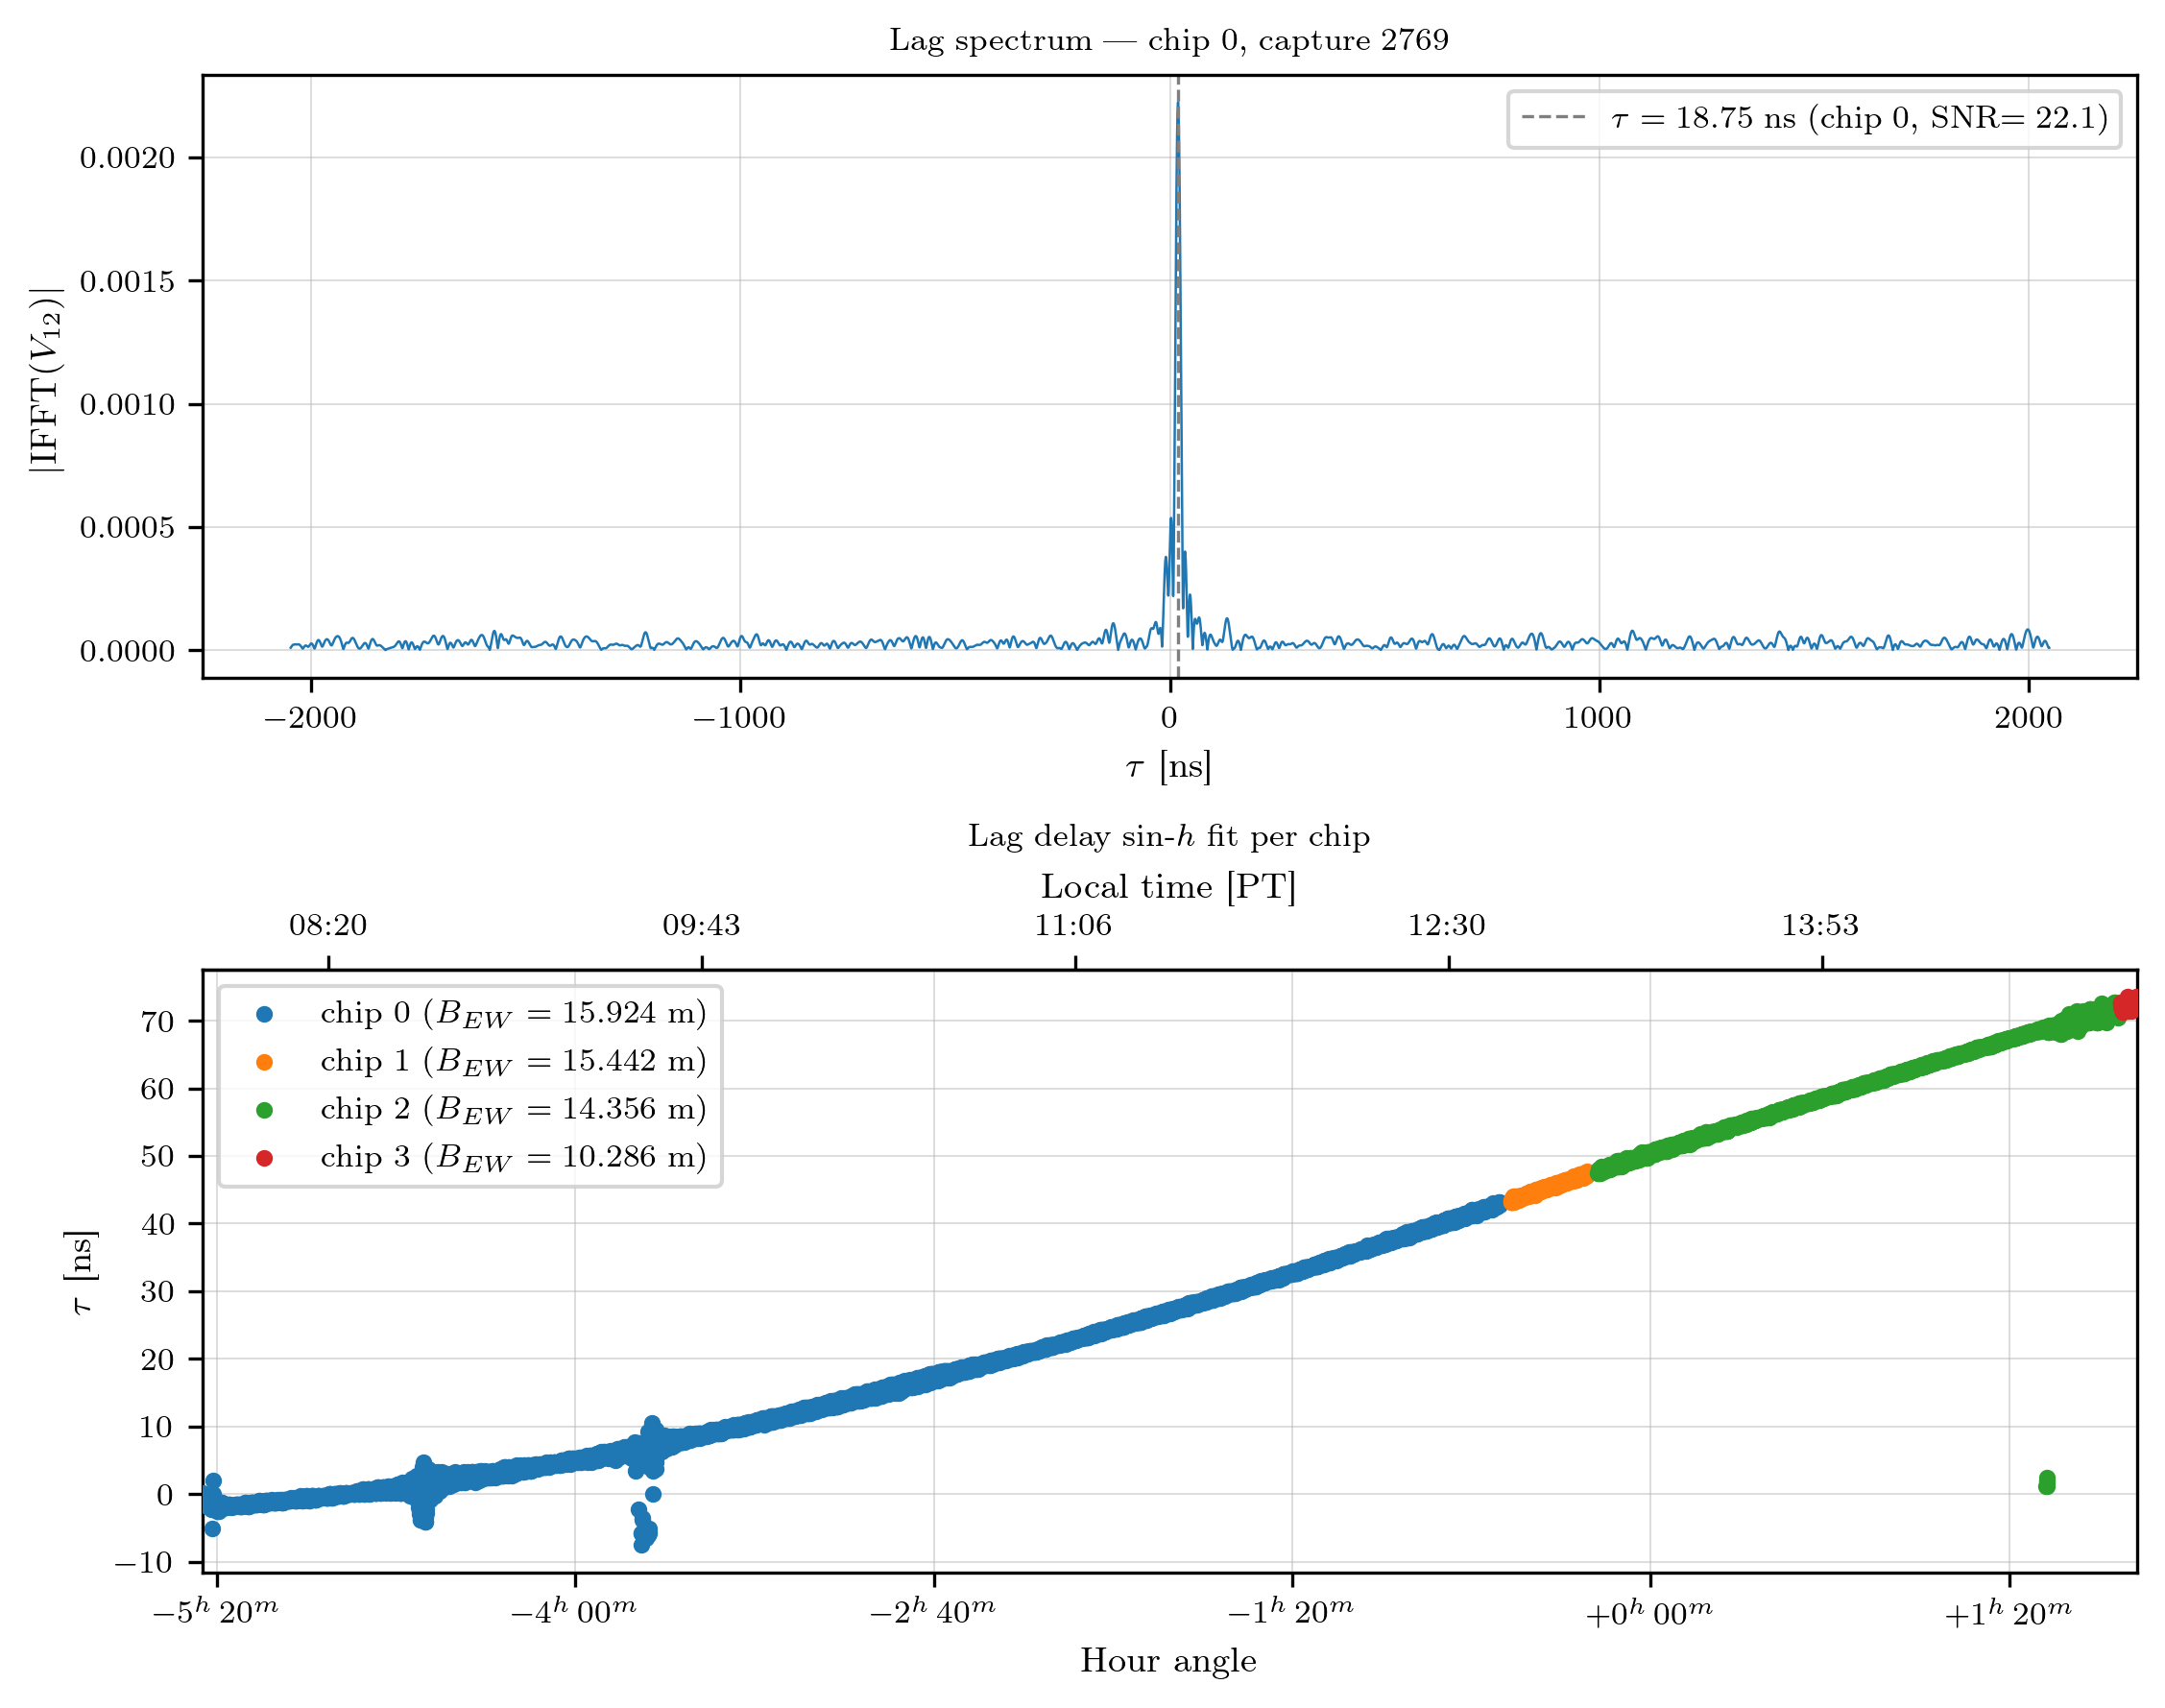

In [7]:
# ---------------------------------------------------------------------------
# Lag-spectrum delay — IFFT of cross-spectrum per capture, per chip
#
# lag(τ) = IFFT(V(ν));  peak of |lag| gives geometric delay directly.
# Fit  τ(h) = A·sin(h) + τ_inst  per chip to extract B_EW.
# ---------------------------------------------------------------------------

PAD_FAC = 16
N_pad   = N_CH * PAD_FAC
_tau_axis_ns = np.fft.fftshift(np.fft.fftfreq(N_pad, d=DF_HZ)) * 1e9
_C_lag = 299792458.0

_tau_lag_chips      = []
_lag_snr_chips      = []
_B_EW_lag_chips     = []
_B_EW_lag_err_chips = []
_coeffs_lag_chips   = []
_sin_h_lag_chips    = []

for c, (ha_c, dc_c, unix_c) in enumerate(zip(ha_chips, corr_dc_chips, unix_chips)):
    nc = N_caps[c]
    _tau_lag = np.full(nc, np.nan)
    _lag_snr = np.full(nc, np.nan)

    for n in range(nc):
        vis = dc_c[n, :].copy()
        for _k in BAD_CHANNELS:
            _lo = _k - 1 if _k > 0 else _k + 1
            _hi = _k + 1 if _k < N_CH - 1 else _k - 1
            vis[_k] = (vis[_lo] + vis[_hi]) / 2
        lag = np.fft.fftshift(np.fft.ifft(vis, n=N_pad))
        amp = np.abs(lag)
        i_pk = np.argmax(amp)
        _tau_lag[n] = _tau_axis_ns[i_pk]
        mask = np.ones(N_pad, dtype=bool)
        mask[max(0, i_pk - 5) : min(N_pad, i_pk + 6)] = False
        _lag_snr[n] = amp[i_pk] / amp[mask].std()

    _dec_lag     = np.mean([get_sun(Time(t, format='unix')).dec.deg for t in unix_c])
    _cos_dec_lag = np.cos(np.radians(_dec_lag))
    _sin_h_lag   = np.sin(np.radians(ha_c))
    _valid_lag   = np.isfinite(_tau_lag)

    _coeffs_lag, (_res_lag, *_) = np.polynomial.polynomial.polyfit(
        _sin_h_lag[_valid_lag], _tau_lag[_valid_lag], 1, full=True
    )
    _B_EW_lag = _coeffs_lag[1] * 1e-9 * _C_lag / _cos_dec_lag

    _nl            = _valid_lag.sum()
    _resid_std_lag = np.sqrt(_res_lag[0] / (_nl - 2)) if len(_res_lag) else np.nan
    _sin_h_rms_lag = np.sqrt(np.sum((_sin_h_lag[_valid_lag] - _sin_h_lag[_valid_lag].mean())**2))
    _B_EW_lag_err  = _resid_std_lag * 1e-9 * _C_lag / (_cos_dec_lag * _sin_h_rms_lag)

    _tau_lag_chips.append(_tau_lag)
    _lag_snr_chips.append(_lag_snr)
    _B_EW_lag_chips.append(_B_EW_lag)
    _B_EW_lag_err_chips.append(_B_EW_lag_err)
    _coeffs_lag_chips.append(_coeffs_lag)
    _sin_h_lag_chips.append(_sin_h_lag)

    print(f'Chip {c}:  B_EW = {_B_EW_lag:.4f} ± {_B_EW_lag_err:.4f} m'
          f'  |  τ_inst = {_coeffs_lag[0]:.4f} ns'
          f'  |  Lag SNR mean={np.nanmean(_lag_snr):.1f}  min={np.nanmin(_lag_snr):.1f}')

# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------

_example_chip_idx = int(np.argmax(N_caps))
_example_capture_idx = N_caps[_example_chip_idx] // 2
_vis_ex = corr_dc_chips[_example_chip_idx][_example_capture_idx, :].copy()
for _k in BAD_CHANNELS:
    _lo = _k - 1 if _k > 0 else _k + 1
    _hi = _k + 1 if _k < N_CH - 1 else _k - 1
    _vis_ex[_k] = (_vis_ex[_lo] + _vis_ex[_hi]) / 2
_lag_ex = np.fft.fftshift(np.fft.ifft(_vis_ex, n=N_pad))

fig, axes = plot_lag_delay_summary(
    tau_axis_ns=_tau_axis_ns,
    lag_amp=np.abs(_lag_ex),
    tau_peak_ns=_tau_lag_chips[_example_chip_idx][_example_capture_idx],
    lag_snr=_lag_snr_chips[_example_chip_idx][_example_capture_idx],
    example_chip_idx=_example_chip_idx,
    capture_index=_example_capture_idx,
    ha_chips=ha_chips,
    tau_lag_chips=_tau_lag_chips,
    baseline_lag_chips=_B_EW_lag_chips,
    sin_h_lag_chips=_sin_h_lag_chips,
    coeffs_lag_chips=_coeffs_lag_chips,
    ha_limits_deg=(ha_deg.min(), ha_deg.max()),
    unix_chips=unix_chips,
)
plt.show()
